# Impact of Modified Gravity $c_s^2$ on observables

In this Notebook, I test the impact of the MG-cs2 model on the cosmological observables.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import utils

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams["legend.framealpha"] = 0.0

In [2]:
# Cosmological parameters for examples
H0 = 67
omegam = 0.319
omegab = 0.049
As = 2.1e-9
ns = 0.96
tau = 0.07

dark_energy_types = ["desi_pp_mean", "wcdm"]
dark_energy_type = "desi_pp_mean"

if dark_energy_type == "desi_pp_mean":
    # DESI DR2 BAO + CMB + Pantheon+ mean
    w0 = -0.838
    wa = -0.62
elif dark_energy_type == "wcdm":
    w0 = -0.8
    wa = 0
else:
    raise Exception(f"Unsupported dark_energy_type {dark_energy_type}; supported values are {dark_energy_types}.")

# Derived parameters
h = H0/100
omegac = omegam - omegab
ombh2 = omegab*h*h
omch2 = omegac*h*h

# k, z grid for power spectrum
ks = np.logspace(-4, -0.9, 256)
redshifts = np.linspace(0, 3, 256)

In [3]:
base_case = {"label": "GR", "use_cs2": False, "cs2_0": 1, "alpha_K_0": 1 }
cases1 = {
    "half": {"label": "$c_s^2 = 0.5$", "use_cs2": True,  "cs2_0": 0.5, "alpha_K_0": 1 },
    "one":  {"label": "$c_s^2 = 1$",   "use_cs2": True,  "cs2_0": 1,   "alpha_K_0": 1 },
    "two":  {"label": "$c_s^2 = 2$",   "use_cs2": True,  "cs2_0": 2,   "alpha_K_0": 1 },
}

cases2 = {
    "half": {"label": "$c_s^2 = 0.5$", "use_cs2": True,  "cs2_0": 0.5, "alpha_K_0": 3 },
    "one":  {"label": "$c_s^2 = 1$",   "use_cs2": True,  "cs2_0": 1,   "alpha_K_0": 3 },
    "two":  {"label": "$c_s^2 = 2$",   "use_cs2": True,  "cs2_0": 2,   "alpha_K_0": 3 },
}


utils.get_observables(base_case, H0, ombh2, omch2, As, ns, tau, w0, wa, dark_energy_type="ppf", alpha_k_parametrization=1, redshifts=redshifts, ks=ks)
for name, case in cases1.items():
    utils.get_observables(case, H0, ombh2, omch2, As, ns, tau, w0, wa, dark_energy_type="ppf", alpha_k_parametrization=1, redshifts=redshifts, ks=ks)
for name, case in cases2.items():
    utils.get_observables(case, H0, ombh2, omch2, As, ns, tau, w0, wa, dark_energy_type="ppf", alpha_k_parametrization=1, redshifts=redshifts, ks=ks)

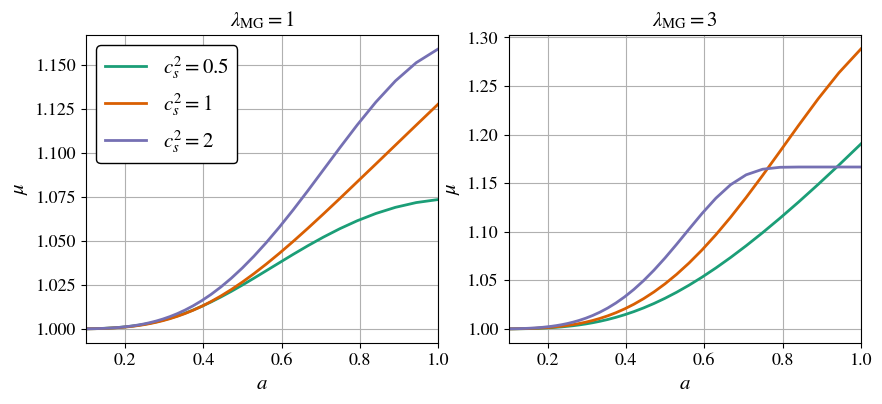

In [4]:
# Plot \mu(a)
# Generated from https://colorbrewer2.org/#type=sequential&scheme=OrRd&n=4
styles = [
    {"lw": 2, "color": "#1b9e77"},
    {"lw": 2, "color": "#d95f02"},
    {"lw": 2, "color": "#7570b3"},
]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for style, (name, case) in zip(styles, cases1.items()):
    a = np.exp(case["log_a"])
    axs[0].plot(a, case["mu"], label=case["label"], **style)

for style, (name, case) in zip(styles, cases2.items()):
    a = np.exp(case["log_a"])
    axs[1].plot(a, case["mu"], label=case["label"], **style)
axs[0].legend(fontsize=15, frameon=True, framealpha=1, edgecolor="black")
axs[0].set_title("$\\lambda_\\mathrm{MG} = 1$", fontsize=15)
axs[1].set_title("$\\lambda_\\mathrm{MG} = 3$", fontsize=15)
for ax in axs:
    ax.set_ylabel("$\\mu$", fontsize=15)
    ax.set_xlabel("$a$", fontsize=15)
    ax.set_xlim([1e-1, 1])
    ax.grid()
    ax.tick_params(axis='both', which='major', labelsize=13)

plt.savefig("plots/mg_cases_mu.pdf", bbox_inches="tight")

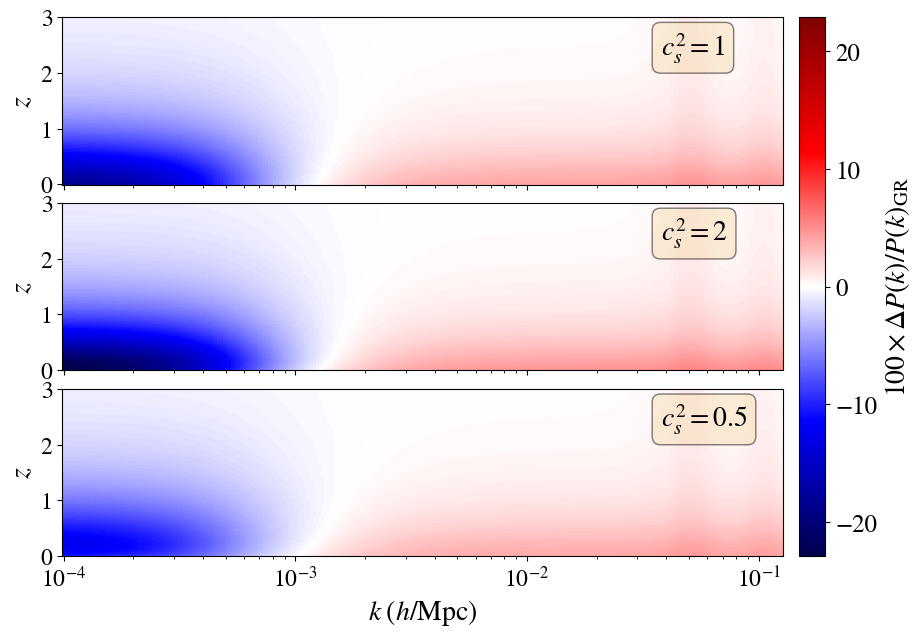

In [ ]:
utils.plot_pk_differences(cases1, base_case, ks, redshifts, "plots/impact_pk_mg_case1.png")
utils.plot_pk_differences(cases2, base_case, ks, redshifts, "plots/impact_pk_mg_case2.png")

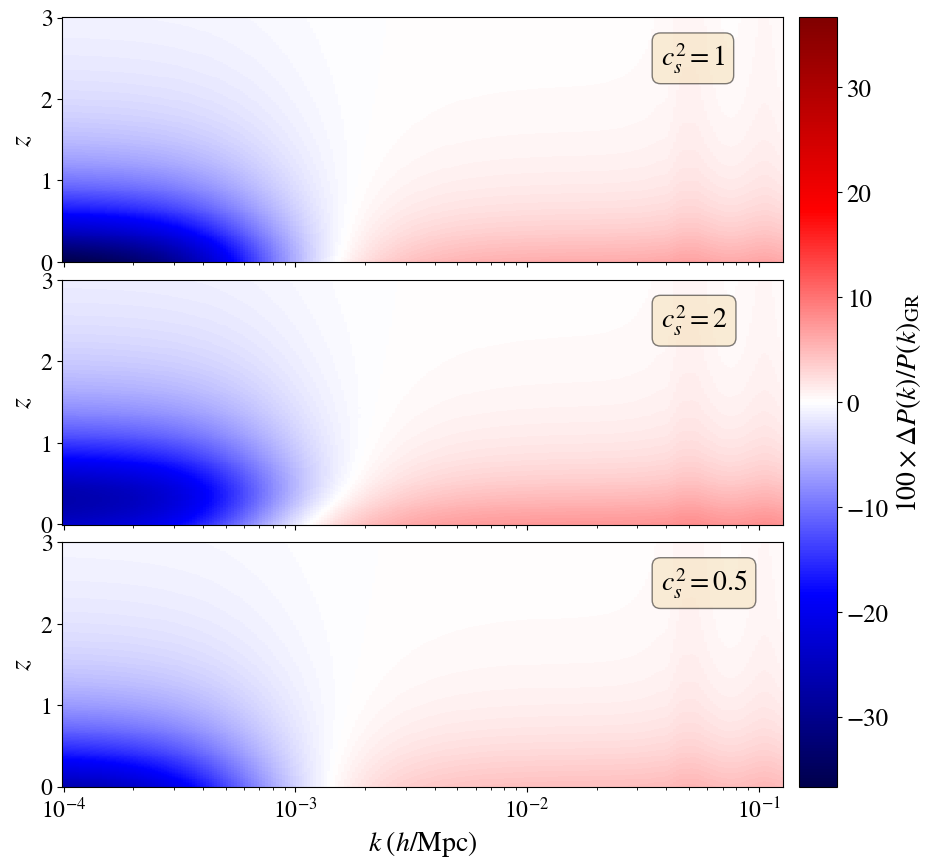

/tmp/ipykernel_22286/2340094649.py:8: RuntimeWarning: invalid value encountered in divide
  axs[0, 0].semilogx(ells_tt, 100*(case["cl_tt"]/cases1["GR"]["cl_tt"] - 1), label=case["label"], **style)
/tmp/ipykernel_22286/2340094649.py:9: RuntimeWarning: invalid value encountered in divide
  axs[0, 1].semilogx(ells_pp, 100*(case["cl_pp"]/cases1["GR"]["cl_pp"] - 1), label=case["label"], **style)
/tmp/ipykernel_22286/2340094649.py:10: RuntimeWarning: invalid value encountered in divide
  axs[1, 0].semilogx(ells_tt, 100*(case["cl_ee"]/cases1["GR"]["cl_ee"] - 1), label=case["label"], **style)


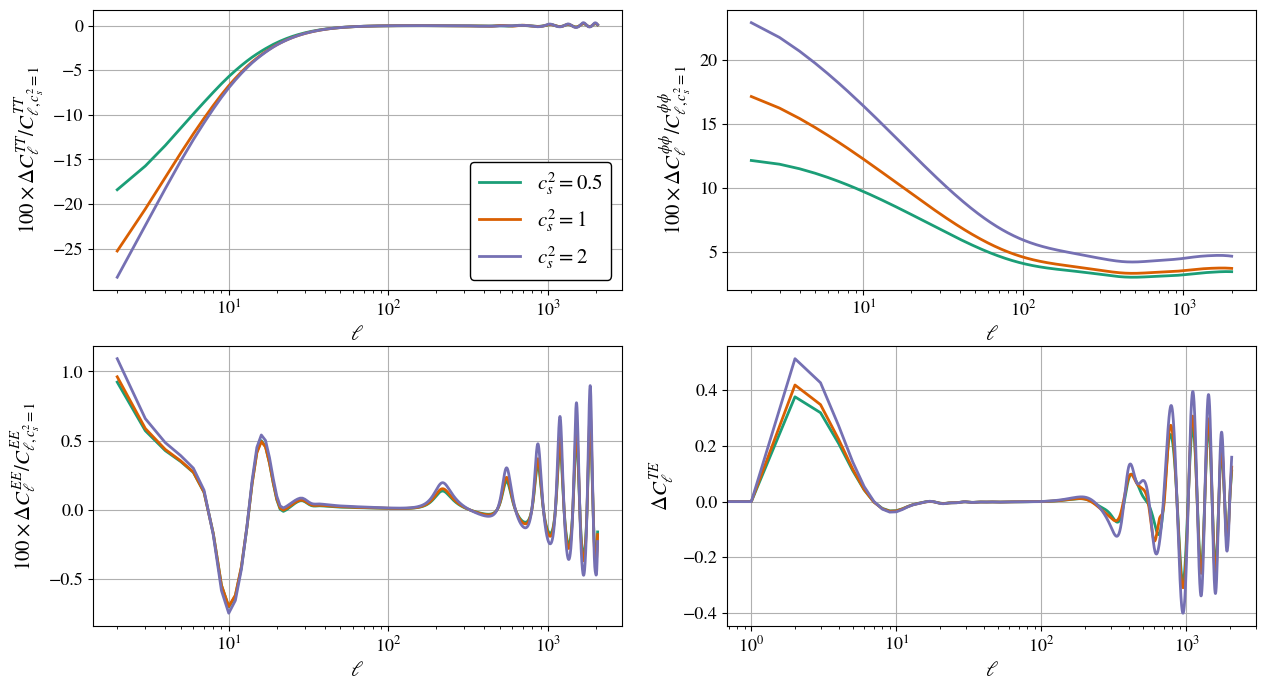

In [ ]:
utils.plot_cmb_differences(cases1, base_case, "plots/impact_cmb_mg_case1.pdf")
utils.plot_cmb_differences(cases2, base_case, "plots/impact_cmb_mg_case2.pdf")

/tmp/ipykernel_22286/1051636288.py:8: RuntimeWarning: invalid value encountered in divide
  axs[0, 0].semilogx(ells_tt, 100*(case["cl_tt"]/cases1["GR"]["cl_tt"] - 1), label=case["label"], **style)
/tmp/ipykernel_22286/1051636288.py:9: RuntimeWarning: invalid value encountered in divide
  axs[0, 1].semilogx(ells_pp, 100*(case["cl_pp"]/cases1["GR"]["cl_pp"] - 1), label=case["label"], **style)
/tmp/ipykernel_22286/1051636288.py:10: RuntimeWarning: invalid value encountered in divide
  axs[1, 0].semilogx(ells_tt, 100*(case["cl_ee"]/cases1["GR"]["cl_ee"] - 1), label=case["label"], **style)


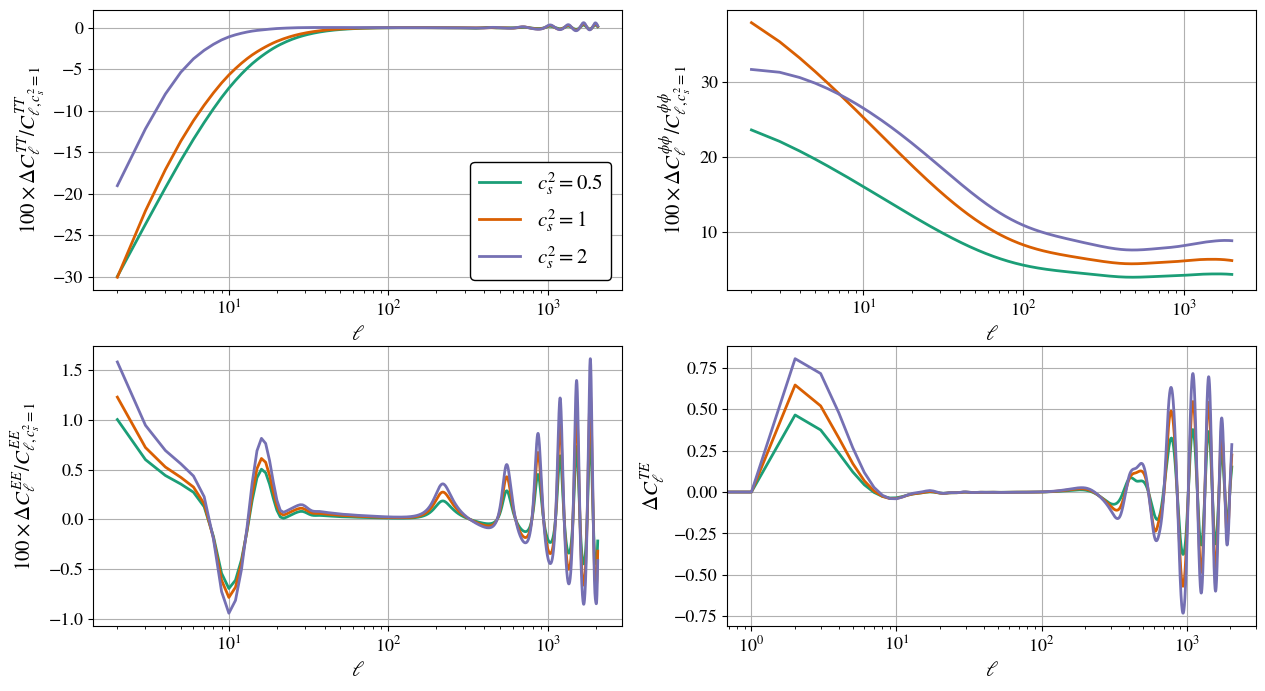